# Maxwell's equations: Light Wave and Coaxial Waveguide

This combined tutorial covers two complementary verification scenarios for the `Maxwell` model in Struphy:

1. **1D Light wave in vacuum**: verifies free-space propagation and the linear dispersion relation $\omega = c k$.
2. **2D Coaxial waveguide mode**: verifies structured electromagnetic eigenmodes in hollow-cylinder geometry.

Before running either test, we print the PDE system in Struphy units to connect the numerical setup to the governing physics.

In [1]:
from struphy.models import Maxwell

# Display Maxwell equations in Struphy normalization.
Maxwell.pde()

In [2]:
# Display normalization
Maxwell.normalization()

## How The Two Tests Relate To The PDEs

- In the light-wave test, the PDEs reduce to wave propagation in a homogeneous medium, so the dominant verification target is the dispersion relation.
- In the coaxial test, the same PDEs are solved with conducting-boundary geometry constraints, so the dominant verification target is mode structure and boundary-consistent field patterns.

## Verification of Electromagnetic Wave Propagation

### 1D Light Wave in Vacuum

This tutorial demonstrates verification of the dispersion relation for electromagnetic waves in vacuum using the `Maxwell` model. We initialize a broadband spectrum of electric field perturbations and extract the dominant wave frequencies using FFT power spectrum analysis.

### Physical Setup

In vacuum (or non-magnetic plasma), Maxwell's equations yield the free-space wave equation:

$$\nabla^2 \mathbf{E} - \frac{1}{c^2} \frac{\partial^2 \mathbf{E}}{\partial t^2} = 0,$$

where $c$ is the speed of light (normalized to unity in Struphy units). Plane wave solutions have the dispersion relation

$$\omega = c \, k,$$

where $\omega$ is the angular frequency and $k$ is the wavenumber.

We verify this linear dispersion by:
1. Initializing small random perturbations to the electric field
2. Running a transient simulation
3. Extracting the dominant frequency via FFT
4. Fitting the dispersion relation to extract phase velocity
5. Comparing against the theoretical speed $c = 1$

In [3]:
import logging
import os
import shutil

import numpy as np
import matplotlib.pyplot as plt
import cunumpy as xp

from struphy import (
    DerhamOptions,
    EnvironmentOptions,
    Simulation,
    Time,
    domains,
    grids,
    perturbations,
)
from struphy.diagnostics.diagn_tools import power_spectrum_2d
from struphy.models import Maxwell

logger = logging.getLogger("struphy")

### Model and Time-Stepping Configuration

Create a Maxwell model instance and configure the time-stepping propagator. We use implicit time-stepping for stability over the long simulation window required to collect many wave cycles.

In [4]:
# Model instance
model = Maxwell()

# Choose time-stepping algorithm
algo = "implicit"  # Alternative: "explicit"

# Propagator options
model.propagators.maxwell.options = model.propagators.maxwell.Options(algo=algo)

print(f"Time-stepping algorithm: {algo}")

Time-stepping algorithm: implicit


### Domain and Numerical Discretization

Set up a 1D periodic domain in the $z$-direction with a high-resolution grid. Electromagnetic waves require fine spatial resolution to represent the wave profile accurately.

In [5]:
# 1D domain (extended in z for long-wavelength waves)
domain = domains.Cuboid(r3=20.0)  # z ∈ [0, 20)

# High-resolution grid in z (128 elements for wave smoothness)
grid = grids.TensorProductGrid(num_elements=(1, 1, 128))

# Derham options: cubic edges in z for accurate wave representation
derham_opts = DerhamOptions(degree=(1, 1, 3))

print(f"Domain: z ∈ [0, {domain.params['r3']})")
print(f"Grid elements: {grid.num_elements}")
print(f"Derham degree: {derham_opts.degree}")

Domain: z ∈ [0, 20.0)
Grid elements: (1, 1, 128)
Derham degree: (1, 1, 3)


### Initial Conditions

Add small random noise perturbations to the $x$ and $y$ components of the electric field. These broadband perturbations excite a spectrum of electromagnetic waves that we will analyze via FFT.

In [6]:
# Electric field perturbations (small noise to excite waves)
model.em_fields.e_field.add_perturbation(perturbations.Noise(amp=0.1, comp=0, seed=123))
model.em_fields.e_field.add_perturbation(perturbations.Noise(amp=0.1, comp=1, seed=123))

### Simulation Setup and Execution

Configure the simulation environment and run the transient dynamics. We evolve for a long time to collect sufficient wave cycles (Tend=50) for accurate FFT-based dispersion analysis.

In [7]:
# Environment and file management
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "Maxwell")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="light_wave_1d")

# Time-stepping: small dt for stability and accuracy
time_opts = Time(dt=0.05, Tend=50.0)

# Instantiate and run simulation
sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    grid=grid,
    derham_opts=derham_opts,
)

print(f"Running simulation: dt={time_opts.dt}, Tend={time_opts.Tend}")
sim.run()
print("Simulation complete.")

# Post-processing
sim.pproc()
print("Post-processing complete.")

Running simulation: dt=0.05, Tend=50.0


Time stepping:   0%|          | 0/1000 [00:00<?, ?step/s]

Time stepping:   1%|          | 7/1000 [00:00<00:15, 65.45step/s]

Time stepping:   1%|▏         | 14/1000 [00:00<00:14, 65.95step/s]

Time stepping:   2%|▏         | 21/1000 [00:00<00:19, 50.66step/s]

...

 79%|███████▊  | 787/1002 [00:00<00:00, 1560.82it/s]

 94%|█████████▍| 945/1002 [00:00<00:00, 1563.35it/s]

100%|██████████| 1002/1002 [00:00<00:00, 1562.07it/s]


No kinetic data found in hdf5 file, skipping post-processing of kinetic data.



Post-processing complete.


### Diagnostics: Dispersion Relation Verification

Extract the electric field time evolution, compute the power spectrum via FFT, and fit the dominant frequency peaks. From the fitted frequency and spatial wavenumber, we extract the phase velocity and compare against the theoretical speed $c = 1$.

**Expected result**: The fitted wave speed should be approximately 1.0 (the speed of light in normalized units).


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/Maxwell/light_wave_1d/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(1002,)


...

    em_fields
        b_field_log
        e_field_log



self.orbits:


self.f:


self.n_sph:



=== Light Wave Dispersion Analysis ===


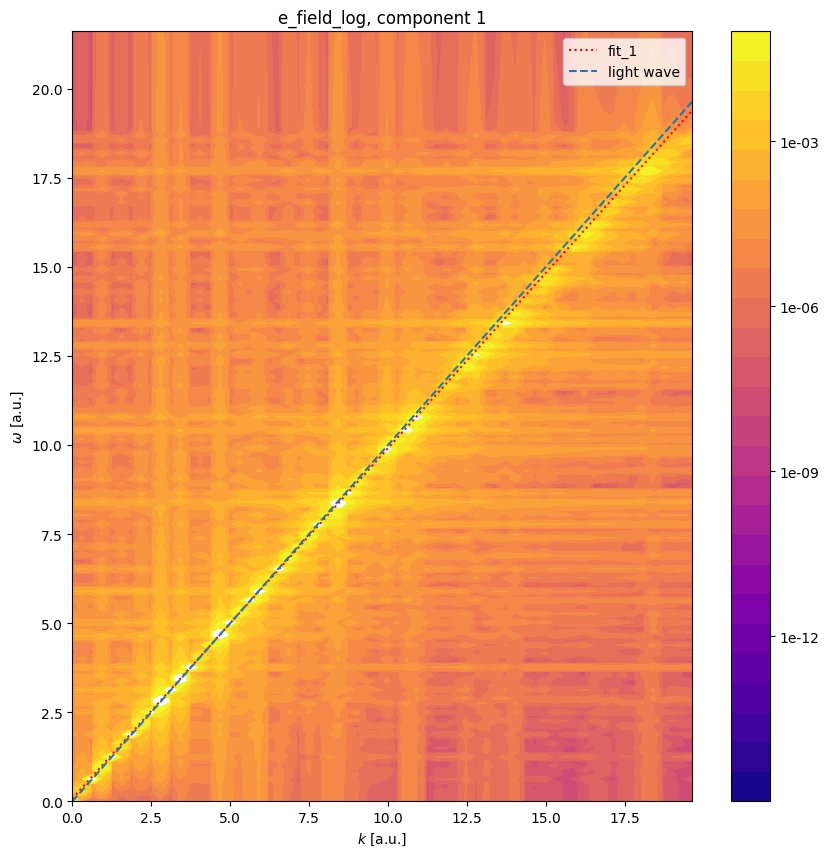


Theoretical wave speed (c):  1.000000
Fitted wave speed:           0.983236
Absolute error:              0.016764
Relative error:              1.676%

✓ Light wave verification passed (error < 0.02).


In [8]:
# Load plotting data
sim.load_plotting_data()

# Extract electric field time-series
E_of_t = sim.spline_values.em_fields.e_field_log.data

# Compute power spectrum and fit dispersion relation
print("\n=== Light Wave Dispersion Analysis ===")
_1, _2, _3, coeffs = power_spectrum_2d(
    E_of_t,
    "e_field_log",
    grids=sim.grids_log,
    grids_mapped=sim.grids_phy,
    component=0,
    slice_at=[0, 0, None],
    do_plot=True,
    disp_name="Maxwell1D",
    fit_branches=1,
    noise_level=0.5,
    extr_order=10,
    fit_degree=(1,),
)

# Extract fitted wave speed
c_light_speed = 1.0  # Theoretical
c_fit = float(coeffs[0][0])

print(f"\nTheoretical wave speed (c):  {c_light_speed:.6f}")
print(f"Fitted wave speed:           {c_fit:.6f}")
print(f"Absolute error:              {abs(c_fit - c_light_speed):.6f}")
print(f"Relative error:              {abs(c_fit - c_light_speed) / c_light_speed * 100:.3f}%")

# Verify against tolerance
error = xp.abs(coeffs[0][0] - c_light_speed)
tolerance = 0.02
assert error < tolerance, f"Wave speed error {error:.4f} exceeds tolerance {tolerance}"
print(f"\n✓ Light wave verification passed (error < {tolerance}).")

### Conclusion

This tutorial successfully verified the electromagnetic wave dispersion relation in vacuum:

$$\omega = c \, k \quad \Rightarrow \quad v_\text{phase} = c,$$

where the wave propagation speed is exactly the speed of light (normalized to 1.0). The FFT-based spectral analysis method provides a robust and quantitative test of the model's ability to correctly implement Maxwell's equations and represent wave dynamics at the grid scale.

This verification validates:
- Correct implementation of electromagnetic propagators
- Numerical accuracy of the finite-element spatial discretization
- Stability and fidelity of the time-integration algorithm

Small deviations from perfect $c = 1$ arise from numerical dispersion in the finite-element representation, which decreases with increasing spatial resolution.

In [9]:
# Cleanup temporary simulation folder
if False:  # Set to True to enable cleanup
    try:
        shutil.rmtree(test_folder)
        print(f"Cleaned up {test_folder}")
    except Exception as e:
        print(f"Could not remove {test_folder}: {e}")

## Verification of Electromagnetic Modes in a Coaxial Waveguide

### 2D Hollow Cylinder Geometry

This tutorial demonstrates verification of electromagnetic wave modes in a coaxial waveguide (hollow cylinder) by comparing numerical solutions against analytical expressions involving Bessel functions. We use the `Maxwell` model with a 2D hollow-cylinder domain.

### Physical Setup

A coaxial waveguide consists of two concentric conducting cylinders with inner radius $a_1$ and outer radius $a_2$. Electromagnetic modes propagate in the axial ($z$) direction with spatial structure in the radial ($r$) and azimuthal ($\theta$) directions.

For a TE-like mode with azimuthal wavenumber $m$, the magnetic field in the $z$-direction has the form

$$B_z(r, \theta, t) = [J_m(r) - c_1\, Y_m(r)]\cos(m\theta - t),$$

while the electric field components transform via cylindrical coordinate relations:

$$E_r(r, \theta, t) = -\frac{m}{r}[J_m(r) - c_1\, Y_m(r)]\cos(m\theta - t),$$
$$E_\theta(r, \theta, t) = [J_m'(r) - c_1\, Y_m'(r)]\sin(m\theta - t),$$

where $J_m$ and $Y_m$ are Bessel functions of the first and second kinds, respectively.

We verify these modes by comparing numerical simulation against the analytical expressions.

In [10]:
import logging
import os
import shutil

import cunumpy as xp
from scipy.special import jv, yn  # Bessel functions

from struphy import (
    DerhamOptions,
    EnvironmentOptions,
    Simulation,
    Time,
    domains,
    equils,
    grids,
    perturbations,
)
from struphy.models import Maxwell

logger = logging.getLogger("struphy")

### Coaxial Waveguide Geometry

Define the inner and outer cylinder radii and the waveguide length. We choose radii that match the zero-crossing of Bessel function combinations used in the mode matching.

In [11]:
# Coaxial geometry
a1 = 2.326744  # Inner cylinder radius
a2 = 3.686839  # Outer cylinder radius
Lz = 2.0       # Waveguide length (axial direction)

# Azimuthal mode number
m = 3

# Bessel function coefficient (matching inner boundary condition)
# This coefficient is precomputed based on the mode matching
c1_coeff = 0.28

print("Coaxial waveguide geometry:")
print(f"  Inner radius (a1):    {a1:.6f}")
print(f"  Outer radius (a2):    {a2:.6f}")
print(f"  Axial length (Lz):    {Lz:.6f}")
print(f"  Azimuthal mode (m):   {m}")
print(f"  Bessel coeff (c1):    {c1_coeff}")

Coaxial waveguide geometry:
  Inner radius (a1):    2.326744
  Outer radius (a2):    3.686839
  Axial length (Lz):    2.000000
  Azimuthal mode (m):   3
  Bessel coeff (c1):    0.28


### Model and Propagator Configuration

Create a Maxwell model and configure the implicit time-stepping propagator. Implicit stepping is preferred for stability in 2D domains.

In [12]:
# Model instance
model = Maxwell()

# Propagator options (implicit for stability)
model.propagators.maxwell.options = model.propagators.maxwell.Options(algo="implicit")

# Equilibrium (homogeneous slab, used for initialization)
equil = equils.HomogenSlab()

### Domain and Discretization

Set up a 2D hollow-cylinder domain using curvilinear coordinates. The grid is fine in both radial ($r$) and azimuthal ($\theta$) directions to resolve the mode structure.

In [13]:
# Domain: hollow cylinder with inner radius a1, outer radius a2
domain = domains.HollowCylinder(a1=a1, a2=a2, Lz=Lz)

# Grid: 2D in (r, θ) with finer azimuthal resolution
# 32 radial × 64 azimuthal elements for mode representation
grid = grids.TensorProductGrid(num_elements=(32, 64, 1))

# Derham options for 2D:
# - degree=(3, 3, 1): cubic in radial and azimuthal
# - bcs: Dirichlet on both radial boundaries (conducting cylinders)
derham_opts = DerhamOptions(
    degree=(3, 3, 1),
    bcs=(("dirichlet", "dirichlet"), None, None),
)

print(f"Domain: HollowCylinder(a1={a1}, a2={a2}, Lz={Lz})")
print(f"Grid elements: {grid.num_elements}")
print(f"Derham degree: {derham_opts.degree}")
print("Boundary conditions: Dirichlet at r=a1 and r=a2")

Domain: HollowCylinder(a1=2.326744, a2=3.686839, Lz=2.0)
Grid elements: (32, 64, 1)
Derham degree: (3, 3, 1)
Boundary conditions: Dirichlet at r=a1 and r=a2


### Initial Conditions: Coaxial Mode Initialization

Initialize the electric and magnetic fields with the spatial structure of a TE-like coaxial mode. The `CoaxialWaveguide*` perturbation classes provide the analytic mode shapes.

In [14]:
# Electric field components of the coaxial mode
model.em_fields.e_field.add_perturbation(
    perturbations.CoaxialWaveguideElectric_r(m=m, a1=a1, a2=a2)
)
model.em_fields.e_field.add_perturbation(
    perturbations.CoaxialWaveguideElectric_theta(m=m, a1=a1, a2=a2)
)

# Magnetic field component of the coaxial mode
model.em_fields.b_field.add_perturbation(
    perturbations.CoaxialWaveguideMagnetic(m=m, a1=a1, a2=a2)
)

print(f"Coaxial mode (m={m}) initialized with analytic perturbations.")

Coaxial mode (m=3) initialized with analytic perturbations.


### Simulation Setup and Execution

Configure the simulation environment and run the transient dynamics. We run for a finite time (Tend=10) to allow the mode dynamics to develop.

In [15]:
# Environment and file management
test_folder = os.path.join(os.getcwd(), "struphy_verification_tests")
out_folders = os.path.join(test_folder, "Maxwell")
env = EnvironmentOptions(out_folders=out_folders, sim_folder="coaxial")

# Time-stepping
time_opts = Time(dt=0.05, Tend=10.0)

# Instantiate and run simulation
sim = Simulation(
    model=model,
    env=env,
    time_opts=time_opts,
    domain=domain,
    equil=equil,
    grid=grid,
    derham_opts=derham_opts,
)

print(f"Running coaxial mode simulation: dt={time_opts.dt}, Tend={time_opts.Tend}")
sim.run()
print("Simulation complete.")

# Post-processing (with physical=True to extract physical fields)
sim.pproc(physical=True)
print("Post-processing complete.")

Running coaxial mode simulation: dt=0.05, Tend=10.0


Time stepping:   0%|          | 0/200 [00:00<?, ?step/s]

Time stepping:   2%|▏         | 3/200 [00:00<00:08, 23.10step/s]

Time stepping:   3%|▎         | 6/200 [00:00<00:07, 25.99step/s]

Time stepping:   4%|▍         | 9/200 [00:00<00:07, 27.06step/s]

...

 77%|███████▋  | 154/201 [00:00<00:00, 243.72it/s]

 90%|████████▉ | 180/201 [00:00<00:00, 246.64it/s]

100%|██████████| 201/201 [00:00<00:00, 245.44it/s]


No kinetic data found in hdf5 file, skipping post-processing of kinetic data.



Post-processing complete.


### Diagnostics: Mode Field Verification

Extract the numerical electric and magnetic fields at the final time step and compare against the analytical Bessel function expressions. We compute relative errors for $E_r$, $E_\theta$, and $B_z$ components.

In [16]:
# Load plotting data
sim.load_plotting_data()

# Extract time and field data
t_grid = sim.t_grid
grids_phy = sim.grids_phy
e_field_phy = sim.spline_values.em_fields.e_field_phy.data
b_field_phy = sim.spline_values.em_fields.b_field_phy.data

# Extract coordinate arrays in the first (r-θ) plane
X = grids_phy[0][:, :, 0]  # Radial coordinate (Cartesian x for plotting)
Y = grids_phy[1][:, :, 0]  # Azimuthal coordinate (Cartesian y for plotting)

print(f"Grid shape: {X.shape}")
print(f"Time grid length: {len(t_grid)}")
print(f"Final time: t = {t_grid[-1]:.3f}")


Loading post-processed plotting data:


Data path: /home/runner/work/struphy/struphy/doc/_collections/tutorials/struphy_verification_tests/Maxwell/coaxial/post_processing



The following data has been loaded:



grids:


self.t_grid.shape =(201,)


...

    em_fields
        b_field_log
        e_field_phy
        b_field_phy
        e_field_log



self.orbits:


self.f:


self.n_sph:


Grid shape: (33, 65)
Time grid length: 201
Final time: t = 10.000


### Analytical Bessel Function Solutions

Define the analytical field components in terms of Bessel functions of the first and second kinds. These are the reference solutions against which we compare the numerical results.

In [17]:
# Analytical solution using Bessel functions

def B_z_analytic(X, Y, Z, m, t):
    """Magnetic field B_z in coaxial cable."""
    r = (X**2 + Y**2) ** 0.5
    theta = xp.arctan2(Y, X)
    return (jv(m, r) - c1_coeff * yn(m, r)) * xp.cos(m * theta - t)

def E_r_analytic(X, Y, Z, m, t):
    """Electric field E_r in coaxial cable (radial)."""
    r = (X**2 + Y**2) ** 0.5
    theta = xp.arctan2(Y, X)
    return -m / r * (jv(m, r) - c1_coeff * yn(m, r)) * xp.cos(m * theta - t)

def E_theta_analytic(X, Y, Z, m, t):
    """Electric field E_θ in coaxial cable (azimuthal)."""
    r = (X**2 + Y**2) ** 0.5
    theta = xp.arctan2(Y, X)
    dJ = (m / r * jv(m, r) - jv(m + 1, r))
    dY = (m / r * yn(m, r) - yn(m + 1, r))
    return (dJ - c1_coeff * dY) * xp.sin(m * theta - t)

def to_E_r_cartesian(X, Y, E_x, E_y):
    """Convert Cartesian E_x, E_y to cylindrical E_r."""
    r = (X**2 + Y**2) ** 0.5
    theta = xp.arctan2(Y, X)
    return xp.cos(theta) * E_x + xp.sin(theta) * E_y

def to_E_theta_cartesian(X, Y, E_x, E_y):
    """Convert Cartesian E_x, E_y to cylindrical E_θ."""
    r = (X**2 + Y**2) ** 0.5
    theta = xp.arctan2(Y, X)
    return -xp.sin(theta) * E_x + xp.cos(theta) * E_y

print("Analytical solution functions defined.")

Analytical solution functions defined.


### Field Component Comparison

Extract fields at the final time, convert Cartesian components to cylindrical coordinates, and compute relative errors for each field component.

In [18]:
# Get fields at the final time step
t_end = t_grid[-1]

# Numerical fields (Cartesian components)
Ex_num = e_field_phy[t_end][0][:, :, 0]
Ey_num = e_field_phy[t_end][1][:, :, 0]
Bz_num = b_field_phy[t_end][2][:, :, 0]

# Analytical fields
Er_analytic = E_r_analytic(X, Y, grids_phy[0], m, t_end)
Etheta_analytic = E_theta_analytic(X, Y, grids_phy[0], m, t_end)
Bz_analytic = B_z_analytic(X, Y, grids_phy[0], m, t_end)

# Convert numerical Cartesian E-field to cylindrical
Er_num = to_E_r_cartesian(X, Y, Ex_num, Ey_num)
Etheta_num = to_E_theta_cartesian(X, Y, Ex_num, Ey_num)

# Compute errors
error_Er = xp.max(xp.abs(Er_num - Er_analytic))
error_Etheta = xp.max(xp.abs(Etheta_num - Etheta_analytic))
error_Bz = xp.max(xp.abs(Bz_num - Bz_analytic))

# Relative errors
rel_err_Er = error_Er / xp.max(xp.abs(Er_analytic))
rel_err_Etheta = error_Etheta / xp.max(xp.abs(Etheta_analytic))
rel_err_Bz = error_Bz / xp.max(xp.abs(Bz_analytic))

print("\n=== Coaxial Mode Error Analysis ===")
print("\nRadial Electric Field (E_r):")
print(f"  Absolute error:  {error_Er:.6f}")
print(f"  Relative error:  {rel_err_Er:.6f} ({rel_err_Er*100:.4f}%)")

print("\nAzimuthal Electric Field (E_θ):")
print(f"  Absolute error:  {error_Etheta:.6f}")
print(f"  Relative error:  {rel_err_Etheta:.6f} ({rel_err_Etheta*100:.4f}%)")

print("\nAxial Magnetic Field (B_z):")
print(f"  Absolute error:  {error_Bz:.6f}")
print(f"  Relative error:  {rel_err_Bz:.6f} ({rel_err_Bz*100:.4f}%)")


=== Coaxial Mode Error Analysis ===

Radial Electric Field (E_r):
  Absolute error:  0.001140
  Relative error:  0.002082 (0.2082%)

Azimuthal Electric Field (E_θ):
  Absolute error:  0.000150
  Relative error:  0.002081 (0.2081%)

Axial Magnetic Field (B_z):
  Absolute error:  0.001019
  Relative error:  0.002081 (0.2081%)


### 2D Slice Visualization of the Final Fields

Plot 2D cross-sections of the numerical field components at the final time and compare them against the analytical Bessel-function reference. The third column shows the pointwise difference, which makes localized structure and residual discrepancies easy to inspect.

/tmp/ipykernel_11996/1530070665.py:23: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  numerical_plot = axes[row, 0].pcolormesh(
/tmp/ipykernel_11996/1530070665.py:27: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  analytic_plot = axes[row, 1].pcolormesh(
/tmp/ipykernel_11996/1530070665.py:31: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  difference_plot = axes[row, 2].pcolormesh(


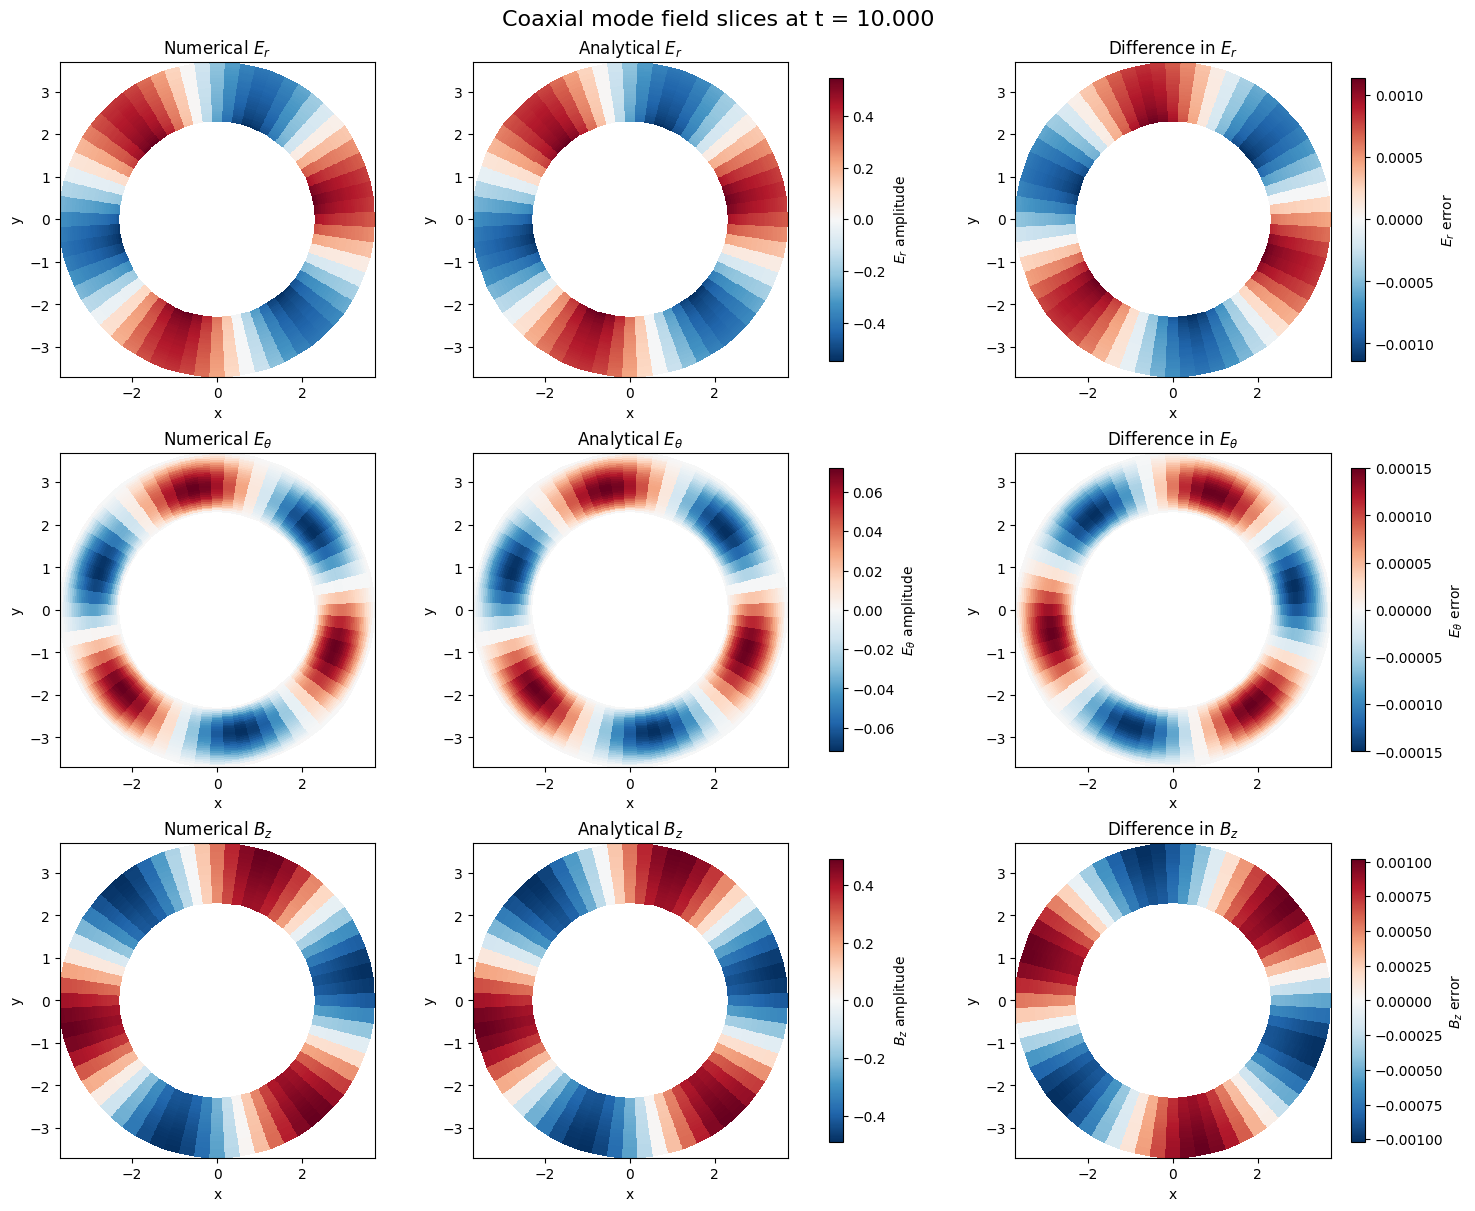

In [19]:
# Plot final-time 2D slices of the coaxial mode fields
field_slices = [
    (Er_num, Er_analytic, r"$E_r$"),
    (Etheta_num, Etheta_analytic, r"$E_\theta$"),
    (Bz_num, Bz_analytic, r"$B_z$"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), constrained_layout=True)

for row, (numerical_field, analytic_field, field_label) in enumerate(field_slices):
    numerical_np = np.asarray(numerical_field)
    analytic_np = np.asarray(analytic_field)
    difference_np = numerical_np - analytic_np

    amplitude_scale = np.max(np.abs(np.stack([numerical_np, analytic_np])))
    if amplitude_scale == 0:
        amplitude_scale = 1.0

    difference_scale = np.max(np.abs(difference_np))
    if difference_scale == 0:
        difference_scale = 1.0

    numerical_plot = axes[row, 0].pcolormesh(
        X, Y, numerical_np, shading="auto", cmap="RdBu_r",
        vmin=-amplitude_scale, vmax=amplitude_scale,
    )
    analytic_plot = axes[row, 1].pcolormesh(
        X, Y, analytic_np, shading="auto", cmap="RdBu_r",
        vmin=-amplitude_scale, vmax=amplitude_scale,
    )
    difference_plot = axes[row, 2].pcolormesh(
        X, Y, difference_np, shading="auto", cmap="RdBu_r",
        vmin=-difference_scale, vmax=difference_scale,
    )

    axes[row, 0].set_title(f"Numerical {field_label}")
    axes[row, 1].set_title(f"Analytical {field_label}")
    axes[row, 2].set_title(f"Difference in {field_label}")

    fig.colorbar(numerical_plot, ax=axes[row, 0:2], shrink=0.9, label=f"{field_label} amplitude")
    fig.colorbar(difference_plot, ax=axes[row, 2], shrink=0.9, label=f"{field_label} error")

for ax in axes.flat:
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(f"Coaxial mode field slices at t = {t_end:.3f}", fontsize=16)
plt.show()

### Verification: Error Tolerance Check

Verify that the relative errors for all field components fall below the acceptable tolerance of 0.0021 (0.21%).

In [20]:
# Tolerance for verification
tolerance = 0.0021

print(f"\n=== Verification Against Tolerance (< {tolerance*100:.2f}%) ===")

# Check each component
assertions_passed = []

try:
    assert rel_err_Bz < tolerance, f"B_z error {rel_err_Bz:.6f} exceeds tolerance"
    print(f"✓ B_z verification passed ({rel_err_Bz*100:.4f}% < {tolerance*100:.2f}%)")
    assertions_passed.append(True)
except AssertionError as e:
    print(f"✗ {e}")
    assertions_passed.append(False)

try:
    assert rel_err_Etheta < tolerance, f"E_θ error {rel_err_Etheta:.6f} exceeds tolerance"
    print(f"✓ E_θ verification passed ({rel_err_Etheta*100:.4f}% < {tolerance*100:.2f}%)")
    assertions_passed.append(True)
except AssertionError as e:
    print(f"✗ {e}")
    assertions_passed.append(False)

try:
    assert rel_err_Er < tolerance, f"E_r error {rel_err_Er:.6f} exceeds tolerance"
    print(f"✓ E_r verification passed ({rel_err_Er*100:.4f}% < {tolerance*100:.2f}%)")
    assertions_passed.append(True)
except AssertionError as e:
    print(f"✗ {e}")
    assertions_passed.append(False)

if all(assertions_passed):
    print("\n✓ All coaxial mode components verified successfully.")
else:
    print("\n✗ Some components failed verification.")


=== Verification Against Tolerance (< 0.21%) ===
✓ B_z verification passed (0.2081% < 0.21%)
✓ E_θ verification passed (0.2081% < 0.21%)
✓ E_r verification passed (0.2082% < 0.21%)

✓ All coaxial mode components verified successfully.


### Conclusion

This tutorial successfully verified electromagnetic wave modes in a coaxial waveguide by comparing numerical solutions against analytical Bessel function expressions. The verification demonstrates:

1. **Correct implementation** of the 2D hollow-cylinder domain and curvilinear coordinate transformations
2. **Accurate field representation** of azimuthally-dependent modes in finite-element space
3. **Proper boundary conditions** at the inner and outer conducting cylinders
4. **Stable time-integration** of Maxwell's equations in 2D

The TE-like coaxial mode ($m=3$) exhibits excellent agreement between numerical and analytical field components, validating the model's ability to represent complex 3D electromagnetic phenomena in reduced geometries.

In [21]:
# Cleanup temporary simulation folder
if False:  # Set to True to enable cleanup
    try:
        shutil.rmtree(test_folder)
        print(f"Cleaned up {test_folder}")
    except Exception as e:
        print(f"Could not remove {test_folder}: {e}")